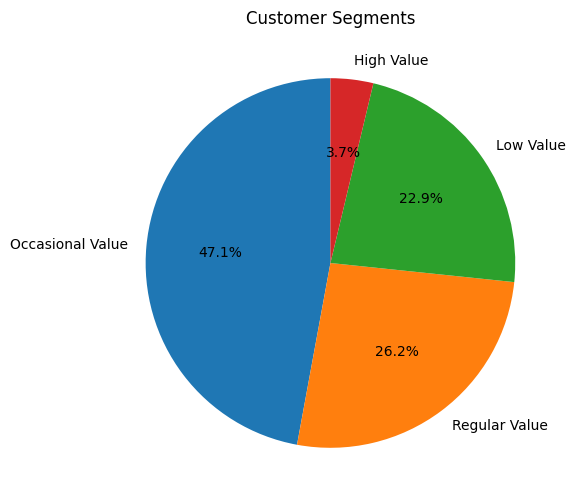

In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv(r"D:\Data Analyst\EXCEL\supplychain\cleaned\final_cleaned.csv")

# Customer summary
customer = df.groupby("customer_id").agg({
    "order_id": "count",
    "net_amount": "sum"
}).reset_index()

customer.columns = ["customer_id", "Total_Orders", "Total_Spend"]

# Scale data
X = customer[["Total_Orders", "Total_Spend"]]
X = StandardScaler().fit_transform(X)

# K-Means
kmeans = KMeans(n_clusters=4, random_state=42)
customer["Cluster"] = kmeans.fit_predict(X)

# Rename clusters (based on spending)
cluster_mean = customer.groupby("Cluster")["Total_Spend"].mean().sort_values()

mapping = {
    cluster_mean.index[0]: "Low Value",
    cluster_mean.index[1]: "Occasional Value",
    cluster_mean.index[2]: "Regular Value",
    cluster_mean.index[3]: "High Value"
}

customer["Segment"] = customer["Cluster"].map(mapping)

# Plot customer percentage
segment_percent = customer["Segment"].value_counts(normalize=True) * 100

plt.figure(figsize=(6,6))
plt.pie(
    segment_percent,
    labels=segment_percent.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Customer Segments")
plt.show()